Importando as bibliotecas iniciais

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
nasa_machine = pd.read_csv('battery_dataset/metadata.csv')

In [62]:
nasa_machine 

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,250,7564,07564.csv,0.9907591663373165,NaN,NaN


Verificando se existem dados faltantes 

In [63]:
nasa_machine.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 591.1 KB


In [64]:
nasa_machine.isnull().sum()

type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               4771
Re                     5609
Rct                    5609
dtype: int64

In [65]:
nasa_machine['type'].value_counts()

type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64

Filtrar o DataFrame para trabalhar com a capacidade

In [66]:
df_descarga = nasa_machine[nasa_machine['type'] == 'discharge'].copy()

df_descarga.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.4671391666146525,NaN,NaN


Criacao de Coluna

In [67]:
# Contagem inicial sequencial de descargas por bateria, para identificar o ciclo de cada bateria
df_descarga['ciclo'] = df_descarga.groupby('battery_id').cumcount() + 1

#Exibem apenas as colunas de interesse, para facilitar a visualização
df_descarga[['battery_id', 'ciclo', 'ambient_temperature', 'Capacity']].head(10)

,battery_id,ciclo,ambient_temperature,Capacity
0,B0047,1,4,1.6743047446975208
4,B0047,2,4,1.5243662105099023
6,B0047,3,4,1.5080762969973425
8,B0047,4,4,1.4835577960067696
10,B0047,5,4,1.4671391666146525
12,B0047,6,4,1.448858156982267
16,B0047,7,4,1.4458534180949325
20,B0047,8,4,1.431118266178283
22,B0047,9,4,1.4192745516578533
24,B0047,10,4,1.3999974221808271


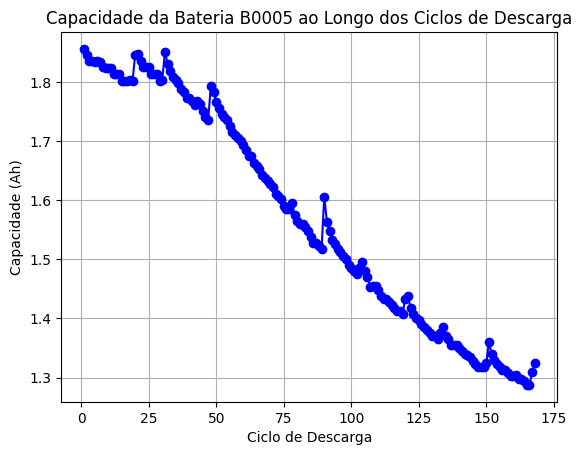

In [68]:
# Convertendo de string para float, para evitar problemas de plotagem
df_descarga['Capacity'] = pd.to_numeric(df_descarga['Capacity'], errors='coerce')
df_descarga['ambient_temperature'] = pd.to_numeric(df_descarga['ambient_temperature'], errors='coerce')
df_descarga = df_descarga.dropna(subset=['Capacity', 'ambient_temperature']).copy()


battery_exemplo = df_descarga[df_descarga['battery_id'] == 'B0005']

plt.Figure(figsize=(10, 6))
plt.plot(battery_exemplo['ciclo'], battery_exemplo['Capacity'], marker='o', linestyle='-', color='b')
plt.xlabel('Ciclo de Descarga')
plt.ylabel('Capacidade (Ah)')
plt.title('Capacidade da Bateria B0005 ao Longo dos Ciclos de Descarga')
plt.grid(True)
plt.show()


Definindo as variáveis (X) e (Y)

In [69]:
X = df_descarga[['ciclo', 'ambient_temperature']].copy()
y = df_descarga['Capacity']

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (2769, 2)
Formato de y: (2769,)



Treino e Teste

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

Modelo RandomForestRegressor

In [72]:
from sklearn.ensemble import RandomForestRegressor

In [73]:
#Criando o modelo
rf_nasa = RandomForestRegressor(n_estimators=100, random_state=42)
#Treinando o modelo com os dados de treino
rf_nasa.fit(x_treino, y_treino)

previsoes = rf_nasa.predict(x_teste)